In [1]:
import os
import numpy as np
import random
import collections
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image


In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # keep deterministic behavior where possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

CHECKPOINTS_DIR = './checkpoints'
RESULTS_DIR = './results'
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Checkpoints dir: {CHECKPOINTS_DIR}")
print(f"Results dir: {RESULTS_DIR}")

Using device: mps
Checkpoints dir: ./checkpoints
Results dir: ./results


In [3]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [4]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [5]:
data_iter = iter(train_loader)
batch = next(data_iter)

# A batch usually consists of features (images) and labels
# The structure depends on how your Dataset.__getitem__ is implemented
if isinstance(batch, list) or isinstance(batch, tuple):
    images, labels = batch
    print(f"Images shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
else:
    # If your dataloader returns a single item
    print(f"Batch shape: {batch.shape}")




Images shape: torch.Size([128, 784])
Labels shape: torch.Size([128])


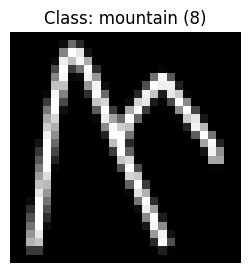

In [6]:
idx = min(60, len(images) - 1)

img = images[idx].numpy().reshape(28, 28)
if img.max() <= 1.0:
    img = img * 255.0
img = img.astype(np.uint8)

class_id = labels[idx].item()
class_names = list(full_train_dataset.classes) if hasattr(full_train_dataset, "classes") else CLASSES
class_name = class_names[class_id]

pil_img = Image.fromarray(img)

plt.figure(figsize=(3, 3))
plt.imshow(pil_img, cmap='gray')
plt.title(f"Class: {class_name} ({class_id})")
plt.axis('off')
plt.show()

In [7]:
# ==========================================
# NORMALIZATION 
# ==========================================
DATA_MEAN = full_train_dataset.x.mean().item()
DATA_STD = full_train_dataset.x.std().item() + 1e-8

# Training epochs
EPOCHS = 40

print(f"DATA_MEAN={DATA_MEAN:.6f}, DATA_STD={DATA_STD:.6f}")
print(f"EPOCHS={EPOCHS}")

DATA_MEAN=0.188342, DATA_STD=0.338611
EPOCHS=40


In [8]:
# ==========================================
# TRAINING (NO AUGMENTATION)
# ==========================================
import pandas as pd
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def _normalize(images):
    return (images.float() - DATA_MEAN) / DATA_STD

def train_one_epoch(model, loader, optimizer, criterion, device, scheduler=None):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for images, labels in loader:
        images = _normalize(images).to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = _normalize(images).to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()
    return total_loss / total_samples, total_correct / total_samples, y_true, y_pred

def fit_champion_variant(model, model_name, train_loader, val_loader, device,
                        epochs=EPOCHS, lr=3e-4, max_lr=3e-3, weight_decay=1e-3,
                        save_best_path=None):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.20,
        anneal_strategy='cos',
        div_factor=10.0,
        final_div_factor=100.0
    )

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'lr': []
    }

    best_val_acc = -1.0
    best_epoch = -1

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scheduler=scheduler
        )
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            if save_best_path is not None:
                torch.save(model.state_dict(), save_best_path)

        print(
            f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
            f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
            f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} | "
            f"Best Val {best_val_acc:.4f} (ep {best_epoch})"
        )

    if save_best_path is not None and os.path.exists(save_best_path):
        print(f"Best checkpoint saved: {save_best_path}")
        model.load_state_dict(torch.load(save_best_path, map_location=device))

    final_val_loss, final_val_acc, y_true, y_pred = evaluate(model, val_loader, criterion, device)

    return {
        'model_name': model_name,
        'params': sum(p.numel() for p in model.parameters()),
        'best_epoch': best_epoch,
        'best_val_acc': best_val_acc,
        'final_val_acc': final_val_acc,
        'final_val_loss': final_val_loss,
        'final_train_acc': history['train_acc'][-1],
        'weight_decay': weight_decay,
        'scheduler': 'OneCycleLR',
        'best_model_path': save_best_path,
        'history': history,
        'y_true': y_true,
        'y_pred': y_pred
    }

In [9]:
# ==========================================
# CHAMPION MLP (2/3/4 HIDDEN-LAYER VARIANTS)
# ==========================================
class ChampionMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15, hidden_layers=3, width=512,
                 dropout=0.20, activation='gelu', use_batchnorm=True):
        super().__init__()
        if hidden_layers not in {2, 3, 4}:
            raise ValueError('hidden_layers must be one of {2, 3, 4}')

        if activation == 'relu':
            act_factory = nn.ReLU
        elif activation == 'gelu':
            act_factory = nn.GELU
        else:
            raise ValueError("activation must be 'relu' or 'gelu'")

        layers = []
        in_dim = input_size

        for _ in range(hidden_layers):
            layers.append(nn.Linear(in_dim, width))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(width))
            layers.append(act_factory())
            layers.append(nn.Dropout(dropout))
            in_dim = width

        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

In [10]:
# ==========================================
# CHAMPION VARIANTS (RELU + GELU, L2 + SCHEDULER)
# ==========================================
VARIANT_LAYERS = [2, 3, 4]
VARIANT_ACTIVATIONS = ['relu', 'gelu']

CHECKPOINT_DIR = globals().get('CHECKPOINTS_DIR', './checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

champion_results = {}

for activation in VARIANT_ACTIVATIONS:
    for n_layers in VARIANT_LAYERS:
        model_name = f"Champion_{activation.upper()}_{n_layers}L"
        checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            f"best_{model_name.lower()}.pth"
        )
        print(f"\n===== Training {model_name} =====")

        seed_everything(SEED)
        model = ChampionMLP(
            input_size=784,
            num_classes=NUM_CLASSES,
            hidden_layers=n_layers,
            width=512,
            dropout=0.20,
            activation=activation,
            use_batchnorm=True
        ).to(DEVICE)

        result = fit_champion_variant(
            model=model,
            model_name=model_name,
            train_loader=train_loader,
            val_loader=val_loader,
            device=DEVICE,
            epochs=EPOCHS,
            lr=3e-4,
            max_lr=3e-3,
            weight_decay=1e-3,
            save_best_path=checkpoint_path
        )

        result['activation'] = activation
        result['hidden_layers'] = n_layers
        champion_results[model_name] = result

print(f"\nCompleted {len(champion_results)} ChampionMLP variants.")


===== Training Champion_RELU_2L =====
[Champion_RELU_2L] Epoch 01/40 | Train Loss 1.4582 Acc 0.5863 | Val Loss 1.1719 Acc 0.6958 | Best Val 0.6958 (ep 1)
[Champion_RELU_2L] Epoch 02/40 | Train Loss 1.1666 Acc 0.6942 | Val Loss 1.0939 Acc 0.7157 | Best Val 0.7157 (ep 2)
[Champion_RELU_2L] Epoch 03/40 | Train Loss 1.0673 Acc 0.7266 | Val Loss 1.0264 Acc 0.7397 | Best Val 0.7397 (ep 3)
[Champion_RELU_2L] Epoch 04/40 | Train Loss 1.0135 Acc 0.7482 | Val Loss 1.0094 Acc 0.7478 | Best Val 0.7478 (ep 4)
[Champion_RELU_2L] Epoch 05/40 | Train Loss 0.9619 Acc 0.7670 | Val Loss 1.0074 Acc 0.7501 | Best Val 0.7501 (ep 5)
[Champion_RELU_2L] Epoch 06/40 | Train Loss 0.9205 Acc 0.7829 | Val Loss 0.9781 Acc 0.7584 | Best Val 0.7584 (ep 6)
[Champion_RELU_2L] Epoch 07/40 | Train Loss 0.8811 Acc 0.7983 | Val Loss 0.9586 Acc 0.7678 | Best Val 0.7678 (ep 7)
[Champion_RELU_2L] Epoch 08/40 | Train Loss 0.8399 Acc 0.8136 | Val Loss 0.9374 Acc 0.7758 | Best Val 0.7758 (ep 8)
[Champion_RELU_2L] Epoch 09/40 | 

,Model,Activation,Hidden Layers,Params,Best Epoch,Best Val Acc,Final Train Acc,Final Val Acc,Generalization Gap,Final Val Loss,Weight Decay,Scheduler,Best Model File
0,Champion_GELU_4L,GELU,4,1201679,37,0.800250,0.993667,0.800250,0.193417,1.008211,0.001,OneCycleLR,./checkpoints/best_champion_gelu_4l.pth
1,Champion_RELU_4L,RELU,4,1201679,37,0.796917,0.981208,0.796917,0.184292,1.011662,0.001,OneCycleLR,./checkpoints/best_champion_relu_4l.pth
2,Champion_RELU_3L,RELU,3,937999,32,0.793500,0.987854,0.793500,0.194354,1.007855,0.001,OneCycleLR,./checkpoints/best_champion_relu_3l.pth
3,Champion_GELU_3L,GELU,3,937999,35,0.792583,0.996646,0.792583,0.204063,0.994086,0.001,OneCycleLR,./checkpoints/best_champion_gelu_3l.pth
4,Champion_GELU_2L,GELU,2,674319,36,0.791417,0.997375,0.791417,0.205958,0.976780,0.001,OneCycleLR,./checkpoints/best_champion_gelu_2l.pth
5,Champion_RELU_2L,RELU,2,674319,33,0.787833,0.992271,0.787833,0.204437,0.990939,0.001,OneCycleLR,./checkpoints/best_champion_relu_2l.pth


Best variant: Champion_GELU_4L | Best Val Acc: 0.8003 | Layers: 4 | Activation: GELU


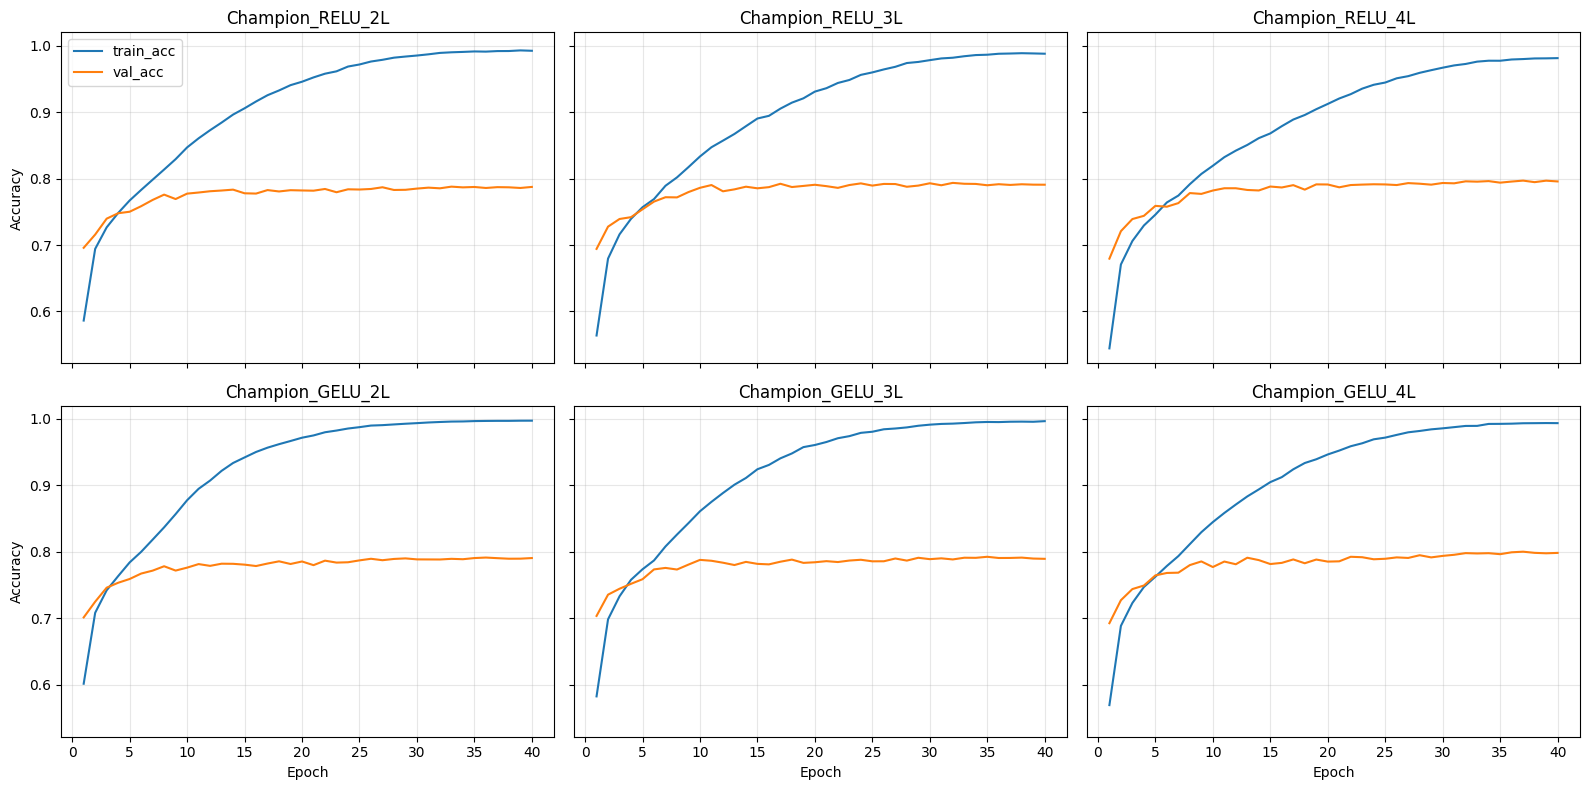

In [11]:
# ==========================================
# RESULTS
# ==========================================
rows = []
for model_name, res in champion_results.items():
    rows.append({
        'Model': model_name,
        'Activation': res['activation'].upper(),
        'Hidden Layers': res['hidden_layers'],
        'Params': res['params'],
        'Best Epoch': res['best_epoch'],
        'Best Val Acc': res['best_val_acc'],
        'Final Train Acc': res['final_train_acc'],
        'Final Val Acc': res['final_val_acc'],
        'Generalization Gap': res['final_train_acc'] - res['final_val_acc'],
        'Final Val Loss': res['final_val_loss'],
        'Weight Decay': res['weight_decay'],
        'Scheduler': res['scheduler'],
        'Best Model File': res.get('best_model_path', '')
    })

comparison_df = pd.DataFrame(rows).sort_values('Best Val Acc', ascending=False).reset_index(drop=True)
display(comparison_df)

winner = comparison_df.iloc[0]
print(
    f"Best variant: {winner['Model']} | Best Val Acc: {winner['Best Val Acc']:.4f} | "
    f"Layers: {int(winner['Hidden Layers'])} | Activation: {winner['Activation']}"
)

# Learning curves (train/val acc)
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
for ax, (model_name, res) in zip(axes.ravel(), champion_results.items()):
    h = res['history']
    epochs = np.arange(1, len(h['train_acc']) + 1)
    ax.plot(epochs, h['train_acc'], label='train_acc')
    ax.plot(epochs, h['val_acc'], label='val_acc')
    ax.set_title(model_name)
    ax.grid(alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel('Epoch')
for ax in axes[:, 0]:
    ax.set_ylabel('Accuracy')
axes[0, 0].legend()
plt.tight_layout()
plt.show()

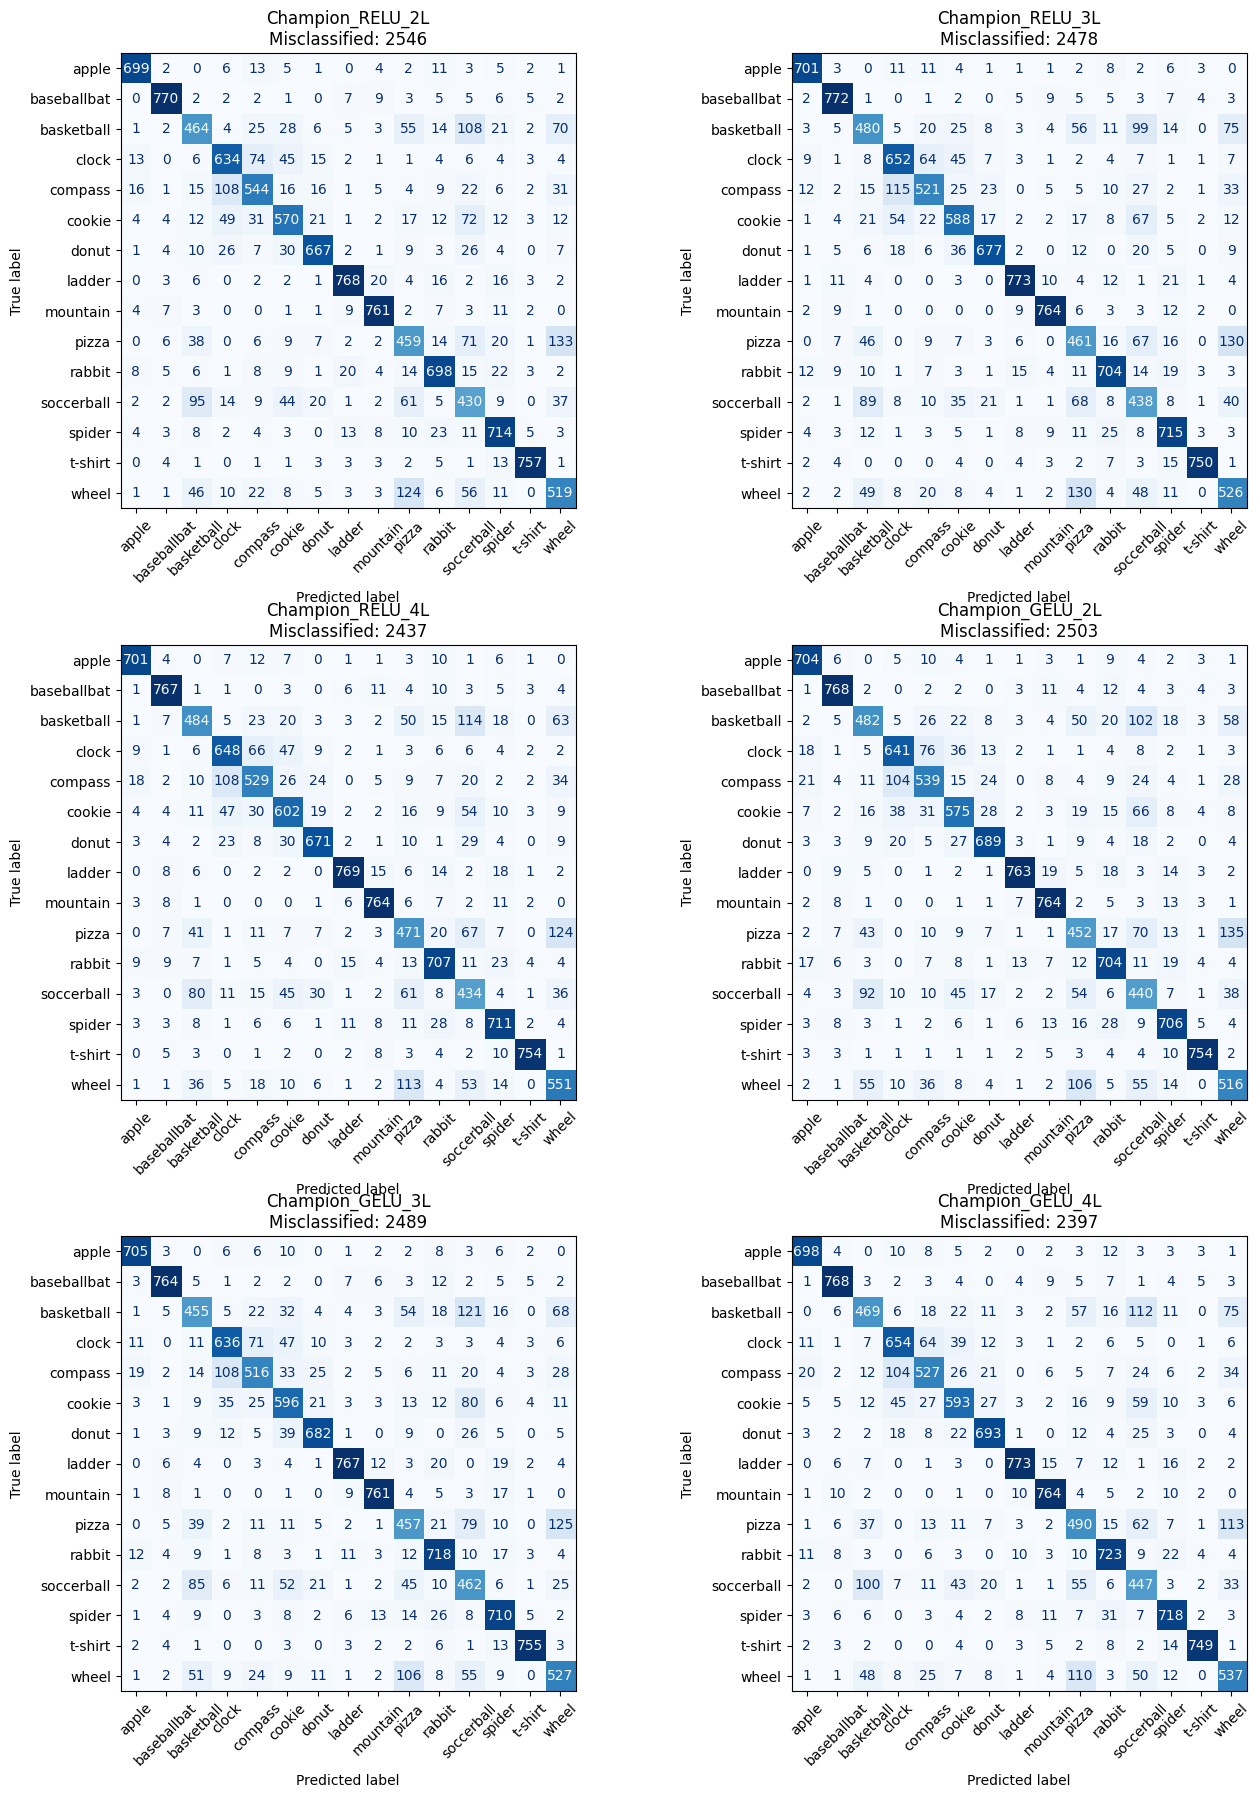

In [12]:
# ==========================================
# 9. CONFUSION MATRICES FOR ALL CHAMPION VARIANTS
# ==========================================
models = list(champion_results.items())
num_models = len(models)

ncols = 2
nrows = int(np.ceil(num_models / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 6 * nrows),
    gridspec_kw={'wspace': 0.04, 'hspace': 0.30}
 )
axes = np.atleast_1d(axes).ravel()

for idx, (model_name, res) in enumerate(models):
    ax = axes[idx]
    cm = confusion_matrix(
        res['y_true'],
        res['y_pred'],
        labels=np.arange(NUM_CLASSES)
    )
    misclassified = int(cm.sum() - np.trace(cm))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f"{model_name}\nMisclassified: {misclassified}")
    ax.tick_params(axis='x', labelrotation=45)

for idx in range(num_models, len(axes)):
    axes[idx].axis('off')

fig.subplots_adjust(left=0.05, right=0.99, top=0.96, bottom=0.05, wspace=0.04, hspace=0.30)
plt.show()

In [13]:
# ==========================================
# TEST AND SUBMISSION EXPORT 
# ==========================================
import re

if 'champion_results' not in globals() or not champion_results:
    raise RuntimeError("No trained Champion variants found. Run the training cell first.")

results_dir = globals().get('RESULTS_DIR', './results')
os.makedirs(results_dir, exist_ok=True)


def sanitize_model_name(model_name):
    return re.sub(r"[^0-9A-Za-z_]+", "_", model_name)


@torch.no_grad()
def run_test_inference(model, test_loader):
    model.eval()
    all_test_preds = []

    for batch in test_loader:
        images = batch[0] if isinstance(batch, (tuple, list)) else batch
        images = _normalize(images).to(DEVICE)
        logits = model(images)
        preds = torch.argmax(logits, dim=1)
        all_test_preds.append(preds.cpu().numpy())

    return np.concatenate(all_test_preds).astype(int)


print(f"Loading test data from {TEST_FILE}...")
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

exported_files = {}
for model_name, res in champion_results.items():
    model = res.get('model', None)
    if model is None:
        model = ChampionMLP(
            input_size=784,
            num_classes=NUM_CLASSES,
            hidden_layers=int(res['hidden_layers']),
            width=512,
            dropout=0.20,
            activation=res['activation'],
            use_batchnorm=True
        ).to(DEVICE)

    checkpoint_path = res.get('best_model_path', '')
    if checkpoint_path and os.path.exists(checkpoint_path):
        state_dict = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(state_dict)
        print(f"[{model_name}] Loaded checkpoint: {checkpoint_path}")
    else:
        print(f"[{model_name}] Checkpoint not found; using in-memory model weights.")

    test_preds = run_test_inference(model, test_loader)

    safe_name = sanitize_model_name(model_name)
    output_file = os.path.join(results_dir, f"submission_{safe_name}.txt")
    with open(output_file, 'w') as f:
        f.write(','.join(map(str, test_preds.tolist())))

    exported_files[model_name] = output_file
    print(f"[{model_name}] Exported {len(test_preds)} predictions -> {output_file}")

if 'comparison_df' in globals() and len(comparison_df) > 0:
    best_model_name = str(comparison_df.iloc[0]['Model'])
else:
    best_model_name = max(champion_results, key=lambda k: champion_results[k]['best_val_acc'])

best_output_file = exported_files.get(best_model_name)
if best_output_file and os.path.exists(best_output_file):
    final_submission_file = os.path.join(results_dir, 'submission.txt')
    with open(best_output_file, 'r') as src, open(final_submission_file, 'w') as dst:
        dst.write(src.read())
    print(f"\nUpdated {final_submission_file} from best model: {best_model_name}")

print("\nAll exported files:")
for model_name, file_name in exported_files.items():
    print(f"- {model_name}: {file_name}")

Loading test data from ./processed_data/quickdraw_test.npz...
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
[Champion_RELU_2L] Loaded checkpoint: ./checkpoints/best_champion_relu_2l.pth
[Champion_RELU_2L] Exported 15000 predictions -> ./results/submission_Champion_RELU_2L.txt
[Champion_RELU_3L] Loaded checkpoint: ./checkpoints/best_champion_relu_3l.pth
[Champion_RELU_3L] Exported 15000 predictions -> ./results/submission_Champion_RELU_3L.txt
[Champion_RELU_4L] Loaded checkpoint: ./checkpoints/best_champion_relu_4l.pth
[Champion_RELU_4L] Exported 15000 predictions -> ./results/submission_Champion_RELU_4L.txt
[Champion_GELU_2L] Loaded checkpoint: ./checkpoints/best_champion_gelu_2l.pth
[Champion_GELU_2L] Exported 15000 predictions -> ./results/submission_Champion_GELU_2L.txt
[Champion_GELU_3L] Loaded checkpoint: ./checkpoints/best_champion_gelu_3l.pth
[Champion_GELU_3L] Exported 15000 predictions -> ./results/submission_Champion_GELU_3L.txt
[Cham